In [3]:
#import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from xgboost import XGBClassifier
import pandas as pd

In [4]:
#Load Dataset
data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=data.target

In [5]:
#split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
#Train XGboost

model=XGBClassifier(scale_pos_weight=2)
model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
#Predict
y_pred=model.predict(X_test)

In [8]:
#Evaluate
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [9]:
#Feature importance
import matplotlib.pyplot as plt 
from xgboost import plot_importance

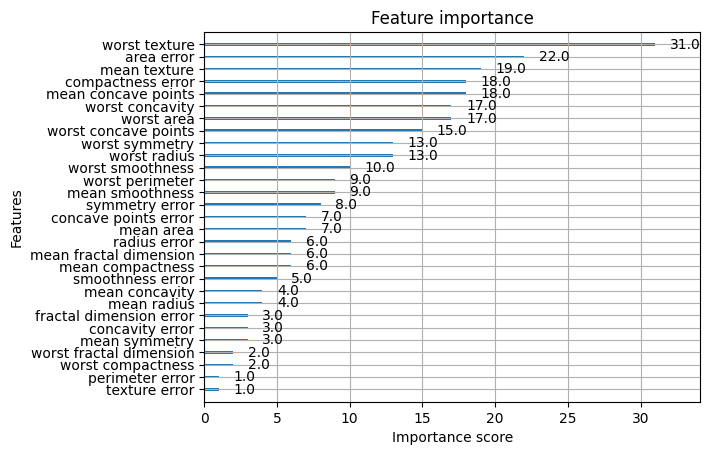

In [10]:
#Plot importance
plot_importance(model)
plt.show()

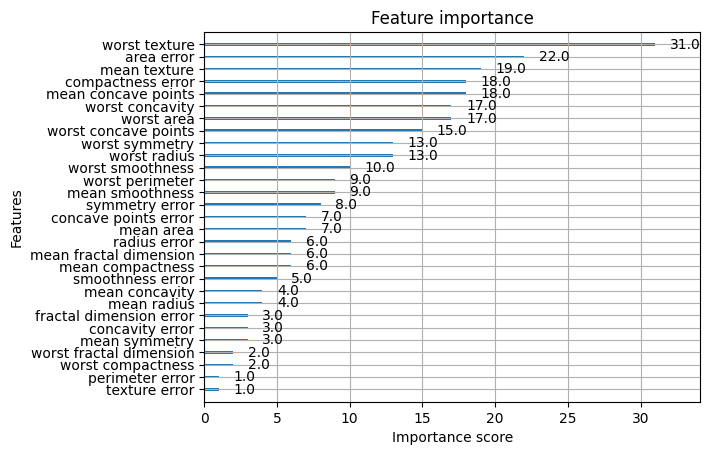

In [11]:
plot_importance(model,importance_type='weight')
plt.show()
plt.show()

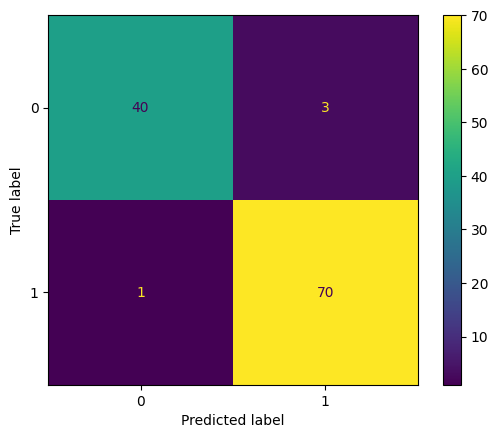

In [12]:
#confusion matrix

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)

disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [13]:
y_prob = model.predict_proba(X_test)[:,1]

In [14]:
# Step 1: get probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Step 2: apply threshold
threshold = 0.2
y_pred_new = (y_prob > threshold).astype(int)

# Step 3: evaluate
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[39  4]
 [ 0 71]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        43
           1       0.95      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



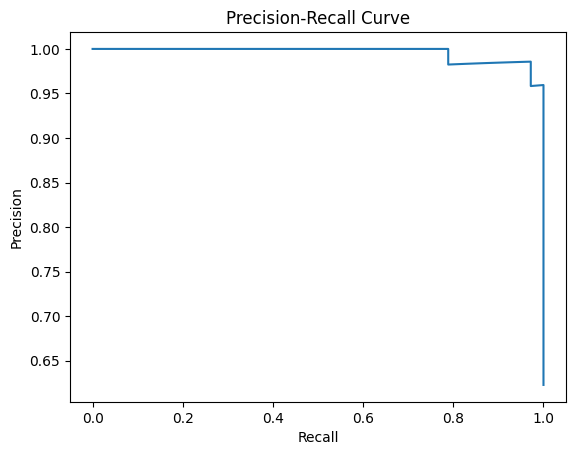

In [15]:
#PR Curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Step 1: get probabilities
y_prob = model.predict_proba(X_test)[:,1]

# Step 2: calculate precision & recall
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Step 3: plot
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [16]:
#Print the best threshold
for i in range(len(thresholds)):
    print(f"Threshold: {thresholds[i]:.2f}, Precision: {precision[i]:.2f}, Recall: {recall[i]:.2f}")

Threshold: 0.00, Precision: 0.62, Recall: 1.00
Threshold: 0.00, Precision: 0.63, Recall: 1.00
Threshold: 0.00, Precision: 0.63, Recall: 1.00
Threshold: 0.00, Precision: 0.64, Recall: 1.00
Threshold: 0.00, Precision: 0.65, Recall: 1.00
Threshold: 0.00, Precision: 0.65, Recall: 1.00
Threshold: 0.00, Precision: 0.66, Recall: 1.00
Threshold: 0.00, Precision: 0.67, Recall: 1.00
Threshold: 0.00, Precision: 0.68, Recall: 1.00
Threshold: 0.00, Precision: 0.68, Recall: 1.00
Threshold: 0.00, Precision: 0.69, Recall: 1.00
Threshold: 0.00, Precision: 0.70, Recall: 1.00
Threshold: 0.00, Precision: 0.70, Recall: 1.00
Threshold: 0.00, Precision: 0.71, Recall: 1.00
Threshold: 0.00, Precision: 0.72, Recall: 1.00
Threshold: 0.00, Precision: 0.72, Recall: 1.00
Threshold: 0.00, Precision: 0.73, Recall: 1.00
Threshold: 0.00, Precision: 0.74, Recall: 1.00
Threshold: 0.00, Precision: 0.75, Recall: 1.00
Threshold: 0.00, Precision: 0.76, Recall: 1.00
Threshold: 0.00, Precision: 0.76, Recall: 1.00
Threshold: 0.

PermutationExplainer explainer: 115it [00:14,  5.31it/s]                         
C:\Users\14162\AppData\Local\Temp\ipykernel_14700\3534154247.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


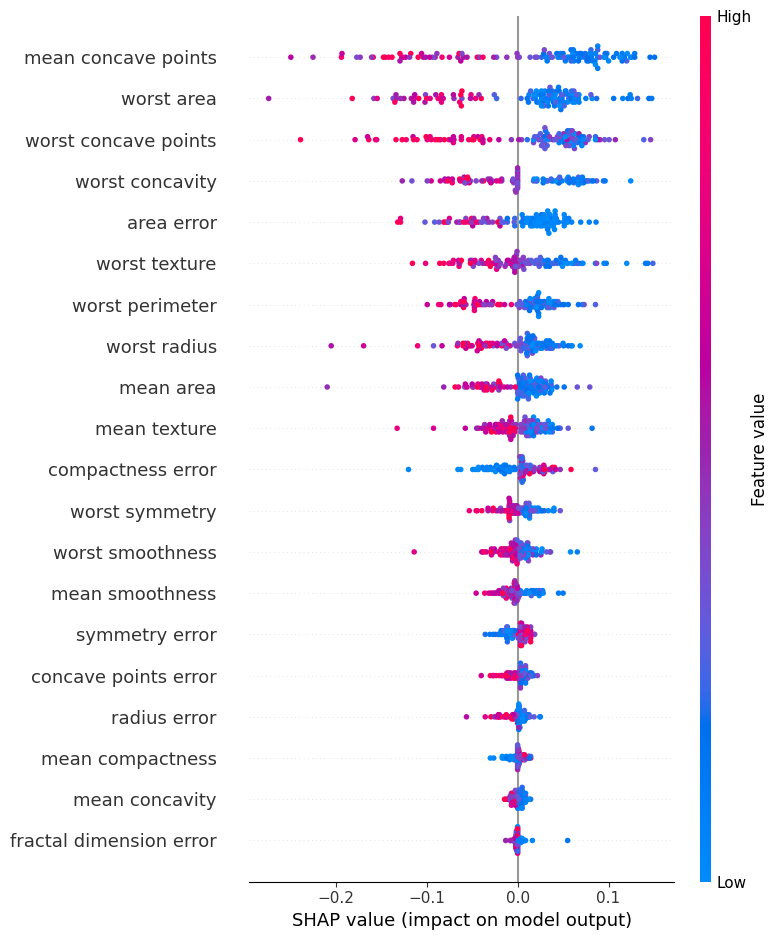

In [25]:
import shap

explainer = shap.Explainer(model.predict, X_train)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)